In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("default")

In [20]:
df = pd.read_csv("data/final_dataset.csv")

print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (196943, 23)


,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


date                               object
station                            object
TMAX                              float64
state                              object
id                                 object
elevation                         float64
disasters_count                   float64
heat_related_disaster_count       float64
heat_related_area_count           float64
heat_related_any                  float64
heat_related_counties_affected    float64
state_fips                          int64
p_pov                             float64
p_unemp                           float64
p_nohsdp                          float64
p_uninsur                         float64
p_imperv                          float64
p_treec                           float64
p_age65                           float64
p_asthma                          float64
overall_score                     float64
hhb_score                         float64
pop_state_sum                     float64
dtype: object

In [21]:
target = "heat_related_any"

display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))

0.0    195781
1.0      1162
Name: heat_related_any, dtype: int64

0.0    0.9941
1.0    0.0059
Name: heat_related_any, dtype: float64

In [22]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear

display(df[["date", "year", "month", "day_of_year"]].head())

,date,year,month,day_of_year
0,2020-01-01,2020,1,1
1,2020-01-02,2020,1,2
2,2020-01-03,2020,1,3
3,2020-01-04,2020,1,4
4,2020-01-05,2020,1,5


In [ ]:
predictors = [
    "TMAX",
    "elevation",
    "disasters_count",
    "p_pov",
    "p_unemp",
    "p_nohsdp",
    "p_uninsur",
    "p_imperv",
    "p_treec",
    "p_age65",
    "p_asthma",
    "overall_score",
    "hhb_score",
    "pop_state_sum",
    "year",
    "month",
    "day_of_year"
]

data = df[[target] + predictors].copy()

print(data.shape)
display(data.head())

(196943, 18)


,heat_related_any,TMAX,elevation,disasters_count,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,day_of_year
0,0.0,56.0,187.7,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,1
1,0.0,70.0,187.7,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,2
2,0.0,65.0,187.7,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,3
3,0.0,57.0,187.7,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,4
4,0.0,57.0,187.7,0.0,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,5


In [24]:
data = data.dropna()

print("Shape after dropping missing values:", data.shape)
display(data[target].value_counts())

Shape after dropping missing values: (196943, 18)


0.0    195781
1.0      1162
Name: heat_related_any, dtype: int64

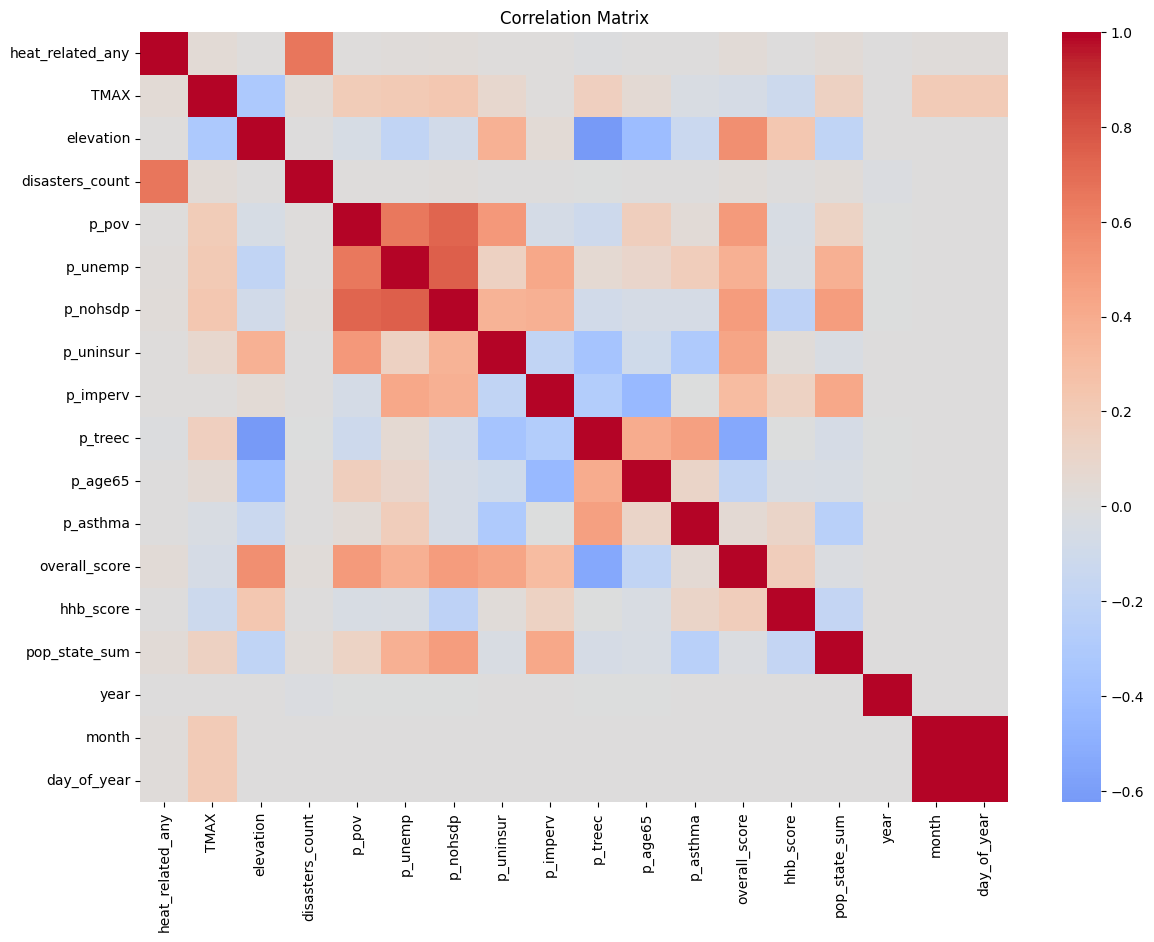

In [ ]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = data[predictors]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining outcome distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting outcome distribution:")
display(y_test.value_counts(normalize=True))

Training shape: (147707, 17)
Testing shape: (49236, 17)

Training outcome distribution:


0.0    0.994103
1.0    0.005897
Name: heat_related_any, dtype: float64


Testing outcome distribution:


0.0    0.99409
1.0    0.00591
Name: heat_related_any, dtype: float64

In [ ]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

display(X_train_const.head())

,const,TMAX,elevation,disasters_count,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,day_of_year
63509,1.0,79.0,42.0,0.0,11.762435,4.288483,8.022571,5.115797,20.975702,37.280175,15.077577,10.142960,0.392512,0.405287,5773492.0,2022,3,66
17620,1.0,44.0,3383.3,0.0,16.111322,4.310988,8.377217,7.560296,24.659369,8.589071,13.852912,10.463270,0.553675,0.560786,5029092.0,2021,10,283
50164,1.0,84.0,205.7,0.0,20.678240,6.220104,11.151210,6.858672,35.896863,12.707190,15.270326,9.771599,0.464714,0.539061,12832475.0,2022,8,224
159796,1.0,54.0,2493.0,0.0,18.034941,3.704825,7.927666,9.642357,25.846122,9.335086,10.988153,10.252101,0.571247,0.817113,2788211.0,2023,4,111
176906,1.0,62.0,1633.7,0.0,17.526500,4.915139,9.036505,6.028113,24.737152,28.247935,15.227894,10.941071,0.551371,0.626779,6724370.0,2022,7,189


In [ ]:
logit_model = sm.Logit(y_train, X_train_const).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.006961
         Iterations 19
                           Logit Regression Results                           
Dep. Variable:       heat_related_any   No. Observations:               147707
Model:                          Logit   Df Residuals:                   147689
Method:                           MLE   Df Model:                           17
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.8074
Time:                        22:21:12   Log-Likelihood:                -1028.2
converged:                       True   LL-Null:                       -5339.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -532.7688     88.698     -6.007      0.000    -706.613    -358.924
TMAX         

In [ ]:
print("Likelihood Ratio Test")
print("LL-null:", logit_model.llnull)
print("LL-model:", logit_model.llf)
print("LR statistic:", logit_model.llr)
print("LR p-value:", logit_model.llr_pvalue)

if logit_model.llr_pvalue < 0.05:
    print("Result: Reject H0. The predictors jointly improve model fit.")
else:
    print("Result: Fail to reject H0. The predictors do not jointly improve model fit.")

Likelihood Ratio Test
LL-null: -5339.569399771368
LL-model: -1028.1538795133572
LR statistic: 8622.831040516021
LR p-value: 0.0
Result: Reject H0. The predictors jointly improve model fit.


In [30]:
print("McFadden pseudo R-squared:", logit_model.prsquared)

McFadden pseudo R-squared: 0.8074462934113411


In [31]:
odds_ratios = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Odds_Ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues
})

display(odds_ratios.sort_values("p_value"))

,Coefficient,Odds_Ratio,p_value
disasters_count,8.662139e+00,5.779883e+03,0.000000e+00
TMAX,3.994359e-02,1.040752e+00,3.814185e-22
const,-5.327688e+02,4.182730e-232,1.895060e-09
year,2.552047e-01,1.290726e+00,6.250243e-09
overall_score,1.148158e+01,9.691451e+04,7.517132e-09
p_pov,-2.044981e-01,8.150563e-01,4.384076e-06
p_treec,3.594717e-02,1.036601e+00,6.741976e-05
p_unemp,6.138461e-01,1.847523e+00,7.002206e-05
elevation,4.299827e-04,1.000430e+00,1.163816e-04
p_uninsur,1.200237e-01,1.127524e+00,1.209474e-03


In [32]:
conf = logit_model.conf_int()
conf.columns = ["2.5%", "97.5%"]

odds_ci = pd.DataFrame({
    "Odds_Ratio": np.exp(logit_model.params),
    "CI_2.5%": np.exp(conf["2.5%"]),
    "CI_97.5%": np.exp(conf["97.5%"]),
    "p_value": logit_model.pvalues
})

display(odds_ci.sort_values("p_value"))

,Odds_Ratio,CI_2.5%,CI_97.5%,p_value
disasters_count,5.779883e+03,4.162614e+03,8.025495e+03,0.000000e+00
TMAX,1.040752e+00,1.032365e+00,1.049207e+00,3.814185e-22
const,4.182730e-232,1.323376e-307,1.322015e-156,1.895060e-09
year,1.290726e+00,1.184253e+00,1.406772e+00,6.250243e-09
overall_score,9.691451e+04,1.973442e+03,4.759410e+06,7.517132e-09
p_pov,8.150563e-01,7.469352e-01,8.893900e-01,4.384076e-06
p_treec,1.036601e+00,1.018436e+00,1.055090e+00,6.741976e-05
p_unemp,1.847523e+00,1.365154e+00,2.500335e+00,7.002206e-05
elevation,1.000430e+00,1.000211e+00,1.000649e+00,1.163816e-04
p_uninsur,1.127524e+00,1.048481e+00,1.212525e+00,1.209474e-03


In [33]:
vif_X = sm.add_constant(X_train)

vif_df = pd.DataFrame()
vif_df["Variable"] = vif_X.columns
vif_df["VIF"] = [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]

display(vif_df.sort_values("VIF", ascending=False))

,Variable,VIF
0,const,2.034155e+06
16,month,1.434154e+02
17,day_of_year,1.431462e+02
6,p_nohsdp,7.477494e+00
4,p_pov,6.721054e+00
8,p_imperv,5.246067e+00
9,p_treec,4.514323e+00
12,overall_score,4.233937e+00
5,p_unemp,4.181875e+00
2,elevation,3.484567e+00


In [34]:
reduced_predictors = [
    "TMAX",
    "disasters_count",
    "p_pov",
    "p_unemp",
    "p_nohsdp",
    "p_uninsur",
    "p_imperv",
    "p_treec",
    "p_age65",
    "p_asthma",
    "overall_score",
    "hhb_score",
    "year",
    "month",
    "day_of_year"
]
X_train_reduced = sm.add_constant(X_train[reduced_predictors])

reduced_logit_model = sm.Logit(y_train, X_train_reduced).fit()

print(reduced_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.007046
         Iterations 19
                           Logit Regression Results                           
Dep. Variable:       heat_related_any   No. Observations:               147707
Model:                          Logit   Df Residuals:                   147691
Method:                           MLE   Df Model:                           15
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.8051
Time:                        22:21:21   Log-Likelihood:                -1040.7
converged:                       True   LL-Null:                       -5339.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -529.3195     87.483     -6.051      0.000    -700.783    -357.856
TMAX         

In [45]:
LR_stat = 2 * (logit_model.llf - reduced_logit_model.llf)

df_diff = logit_model.df_model - reduced_logit_model.df_model

p_value = stats.chi2.sf(LR_stat, df_diff)

print("Partial Likelihood-Ratio Test")
print("LR statistic:", LR_stat)
print("Degrees of freedom:", df_diff)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. The removed predictors are jointly significant.")
else:
    print("Result: Fail to reject H0. The removed predictors do not significantly improve model fit.")

Partial Likelihood-Ratio Test
LR statistic: 25.1580534390514
Degrees of freedom: 2.0
p-value: 3.443484306063983e-06
Result: Reject H0. The removed predictors are jointly significant.


In [54]:
y_pred_prob = logit_model.predict(X_test_const)

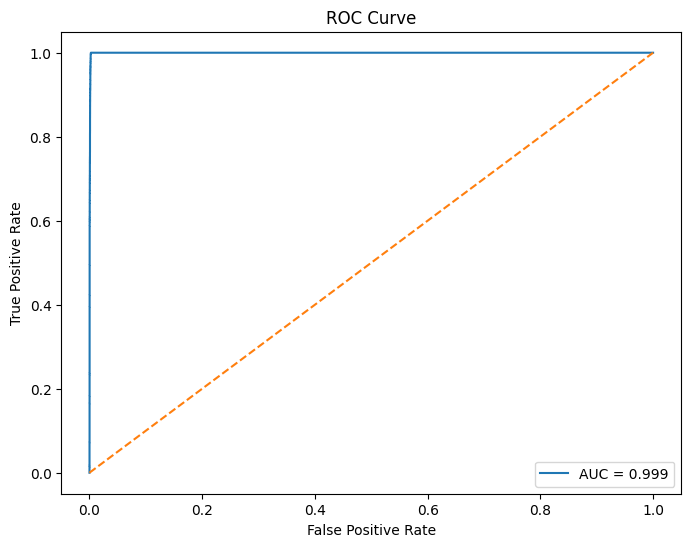

ROC AUC: 0.9994465349457751


In [47]:
auc = roc_auc_score(y_test, y_pred_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC AUC:", auc)

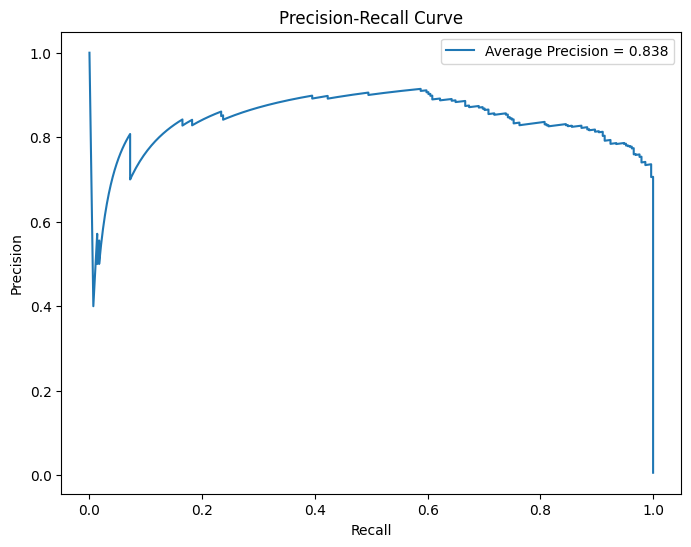

Average Precision Score: 0.8378915140672286


In [48]:
avg_precision = average_precision_score(y_test, y_pred_prob)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("Average Precision Score:", avg_precision)

In [49]:
threshold = 0.10

y_pred_class_010 = (y_pred_prob >= threshold).astype(int)

cm_010 = confusion_matrix(y_test, y_pred_class_010)

display(pd.DataFrame(
    cm_010,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

print(classification_report(y_test, y_pred_class_010))

,Predicted 0,Predicted 1
Actual 0,48837,108
Actual 1,1,290


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     48945
         1.0       0.73      1.00      0.84       291

    accuracy                           1.00     49236
   macro avg       0.86      1.00      0.92     49236
weighted avg       1.00      1.00      1.00     49236



In [50]:
threshold_results = []

for threshold in [0.01, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50]:
    preds = (y_pred_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, preds)
    
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision_val,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,accuracy,sensitivity_recall,specificity,precision,true_positives,false_positives,false_negatives,true_negatives
0,0.010,0.997522,1.000000,0.997507,0.704600,291,122,0,48823
1,0.025,0.997542,0.996564,0.997548,0.707317,290,120,1,48825
2,0.050,0.997624,0.996564,0.997630,0.714286,290,116,1,48829
3,0.100,0.997786,0.996564,0.997793,0.728643,290,108,1,48837
4,0.200,0.997928,0.979381,0.998039,0.748031,285,96,6,48849
5,0.300,0.998152,0.945017,0.998468,0.785714,275,75,16,48870
6,0.500,0.997908,0.804124,0.999060,0.835714,234,46,57,48899


In [51]:
train_pred_prob = logit_model.predict(X_train_const)

residuals_response = y_train - train_pred_prob

residuals_pearson = residuals_response / np.sqrt(train_pred_prob * (1 - train_pred_prob))

residual_df = pd.DataFrame({
    "actual": y_train,
    "predicted_probability": train_pred_prob,
    "response_residual": residuals_response,
    "pearson_residual": residuals_pearson
})

display(residual_df.head())

,actual,predicted_probability,response_residual,pearson_residual
63509,0.0,0.000140,-0.000140,-0.011845
17620,0.0,0.000428,-0.000428,-0.020703
50164,0.0,0.000205,-0.000205,-0.014320
159796,0.0,0.000193,-0.000193,-0.013910
176906,0.0,0.000526,-0.000526,-0.022945


In [52]:
final_summary = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Odds_Ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues
})

display(final_summary.sort_values("p_value"))

,Coefficient,Odds_Ratio,p_value
disasters_count,8.662139e+00,5.779883e+03,0.000000e+00
TMAX,3.994359e-02,1.040752e+00,3.814185e-22
const,-5.327688e+02,4.182730e-232,1.895060e-09
year,2.552047e-01,1.290726e+00,6.250243e-09
overall_score,1.148158e+01,9.691451e+04,7.517132e-09
p_pov,-2.044981e-01,8.150563e-01,4.384076e-06
p_treec,3.594717e-02,1.036601e+00,6.741976e-05
p_unemp,6.138461e-01,1.847523e+00,7.002206e-05
elevation,4.299827e-04,1.000430e+00,1.163816e-04
p_uninsur,1.200237e-01,1.127524e+00,1.209474e-03


In [53]:
print("LOGISTIC REGRESSION INTERPRETATION")
print("-" * 60)

print(f"Outcome variable: {target}")
print(f"Number of observations used: {len(data)}")
print(f"McFadden pseudo R-squared: {logit_model.prsquared:.4f}")
print(f"Likelihood-ratio test p-value: {logit_model.llr_pvalue:.6g}")
print(f"ROC AUC: {auc:.4f}")
print(f"Average precision score: {avg_precision:.4f}")

significant_vars = final_summary[final_summary["p_value"] < 0.05].index.tolist()

print("\nSignificant predictors at alpha = 0.05:")
print(significant_vars)

LOGISTIC REGRESSION INTERPRETATION
------------------------------------------------------------
Outcome variable: heat_related_any
Number of observations used: 196943
McFadden pseudo R-squared: 0.8074
Likelihood-ratio test p-value: 0
ROC AUC: 0.9994
Average precision score: 0.8379

Significant predictors at alpha = 0.05:
['const', 'TMAX', 'elevation', 'disasters_count', 'p_pov', 'p_unemp', 'p_uninsur', 'p_imperv', 'p_treec', 'overall_score', 'pop_state_sum', 'year']


The logistic regression model predicts whether a heat-related disaster occurred using weather, temporal, demographic, and vulnerability indicators. The dataset contains 196,943 observations, but the outcome is highly imbalanced: only 1,162 records, or about 0.59%, are heat-related events. Despite this imbalance, the model fits the data very strongly, with a McFadden pseudo R² of 0.8074, a significant likelihood-ratio test, ROC AUC of 0.9994, and average precision of 0.8379.

The strongest predictors were `disasters_count`, `TMAX`, `year`, and `overall_score`. Higher maximum temperature increased the odds of a heat-related event by about 4.1% per degree, while `disasters_count` had an especially large positive association. Several social vulnerability variables were also significant, including unemployment, uninsured rate, tree cover, impervious surface, poverty, and population size. At the default 0.50 threshold, the model identified 234 of 291 heat-related events, with precision of 0.84 and recall of 0.80. Lowering the threshold to 0.10 improved recall to nearly 1.00 while maintaining precision around 0.73, which may be preferable if the goal is to avoid missing heat-related disaster days.